<a href="https://colab.research.google.com/github/MD-Danish01/ecommerce-review-sentiment-analysis/blob/main/Ecommerce_Review_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-commerce Review Sentiment Analysis

This project classifies e-commerce customer reviews as Positive, Negative, or Neutral using Python, TF-IDF, and Logistic Regression.

## Tech Stack
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- TF-IDF Vectorizer
- Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
data = {
    "review": [
        "The product quality is excellent and worth the price",
        "Amazing product, I am very happy with the purchase",
        "Fast delivery and good packaging",
        "Very useful product and works perfectly",
        "Great quality and value for money",
        "I loved the product, highly recommended",
        "The item is original and performs well",
        "Best purchase I have made recently",
        "Good product with nice build quality",
        "Excellent service and product quality",

        "Very bad product, waste of money",
        "The item stopped working after one day",
        "Poor quality and very disappointing",
        "Worst experience, I will not buy again",
        "Late delivery and damaged packaging",
        "The product is fake and useless",
        "Bad quality, not worth the price",
        "I am unhappy with this purchase",
        "Terrible product and poor customer service",
        "Completely disappointed with the product",

        "The product is okay for the price",
        "Average quality, nothing special",
        "It works fine but could be better",
        "Delivery was normal and product is usable",
        "Not bad, but not very good either",
        "The product is decent for basic use",
        "Quality is acceptable according to price",
        "It is fine, but I expected more",
        "The item is usable but packaging was average",
        "Overall experience was neutral"
    ],
    "sentiment": [
        "positive", "positive", "positive", "positive", "positive",
        "positive", "positive", "positive", "positive", "positive",

        "negative", "negative", "negative", "negative", "negative",
        "negative", "negative", "negative", "negative", "negative",

        "neutral", "neutral", "neutral", "neutral", "neutral",
        "neutral", "neutral", "neutral", "neutral", "neutral"
    ]
}

df = pd.DataFrame(data)
df.head()

,review,sentiment
0,The product quality is excellent and worth the...,positive
1,"Amazing product, I am very happy with the purc...",positive
2,Fast delivery and good packaging,positive
3,Very useful product and works perfectly,positive
4,Great quality and value for money,positive


In [3]:
print("Dataset shape:", df.shape)
print("\nSentiment count:")
print(df["sentiment"].value_counts())

df.sample(5)

Dataset shape: (30, 2)

Sentiment count:
sentiment
positive    10
negative    10
neutral     10
Name: count, dtype: int64


,review,sentiment
3,Very useful product and works perfectly,positive
0,The product quality is excellent and worth the...,positive
21,"Average quality, nothing special",neutral
1,"Amazing product, I am very happy with the purc...",positive
25,The product is decent for basic use,neutral


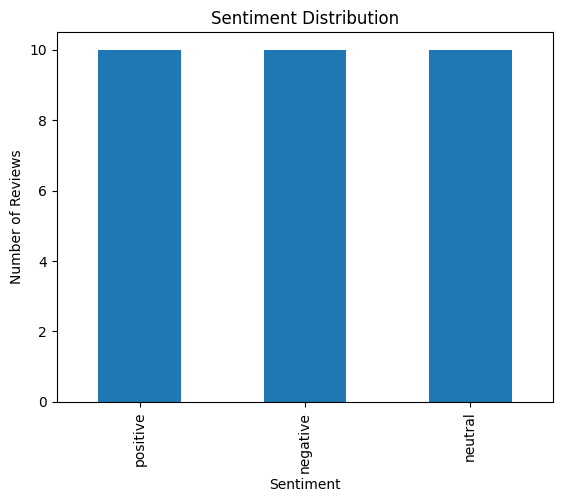

In [4]:
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,The product quality is excellent and worth the...,the product quality is excellent and worth the...,positive
1,"Amazing product, I am very happy with the purc...",amazing product i am very happy with the purchase,positive
2,Fast delivery and good packaging,fast delivery and good packaging,positive
3,Very useful product and works perfectly,very useful product and works perfectly,positive
4,Great quality and value for money,great quality and value for money,positive


In [12]:
X = df["clean_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


In [13]:
vectorizer = TfidfVectorizer(stop_words="english")

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (24, 54)
TF-IDF testing shape: (6, 54)


In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


In [15]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 16.67 %

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.33      0.50      0.40         2
    positive       0.00      0.00      0.00         2

    accuracy                           0.17         6
   macro avg       0.11      0.17      0.13         6
weighted avg       0.11      0.17      0.13         6



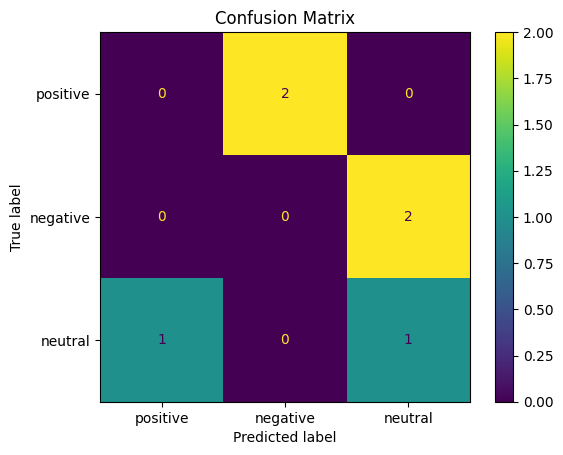

In [16]:
labels = ["positive", "negative", "neutral"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [17]:
def predict_sentiment(review):
    cleaned_review = clean_text(review)
    review_tfidf = vectorizer.transform([cleaned_review])
    prediction = model.predict(review_tfidf)[0]
    return prediction

test_reviews = [
    "The product is amazing and delivery was fast",
    "Worst product, completely waste of money",
    "The product is okay but packaging could be better"
]

for review in test_reviews:
    print("Review:", review)
    print("Predicted Sentiment:", predict_sentiment(review))
    print("-" * 50)

Review: The product is amazing and delivery was fast
Predicted Sentiment: positive
--------------------------------------------------
Review: Worst product, completely waste of money
Predicted Sentiment: negative
--------------------------------------------------
Review: The product is okay but packaging could be better
Predicted Sentiment: neutral
--------------------------------------------------


## Conclusion

In this project, I built a basic sentiment analysis model for e-commerce reviews.  
The project follows a simple machine learning pipeline:

1. Created a review dataset
2. Cleaned text data
3. Converted text into numerical features using TF-IDF
4. Trained a Logistic Regression model
5. Evaluated the model using accuracy, classification report, and confusion matrix
6. Tested the model on custom review examples

This project helped me understand text preprocessing, feature extraction, model training, and sentiment classification.